# Chapter 7 - Feature Engineering II

In this chapter we focus on two practical feature engineering problems:
missing values and outliers. Both problems are common in real datasets, and
both can change the way a model learns from the data.

We will work through the examples to learn about:

- handling missing values by deletion
- filling missing values with univariate imputation
- filling missing values with KNN imputation
- detecting and treating outliers with Z-score and IQR rules

In [1]:
# Common imports used throughout the code
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer, SimpleImputer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. What Missing Values Do

A missing value means that a row has incomplete information for one or more
features. Many machine learning algorithms expect complete numeric or
categorical inputs, so missing values must be handled before modeling.

The chapter groups missing data into three useful categories:

- **MCAR**: missing completely at random, with no relation to observed or
  unobserved values.
- **MAR**: missingness depends on other observed features.
- **MNAR**: missingness depends on the missing value itself.

The handling method should match the data.

Deletion can work for small MCAR missingness; imputation is usually better when we want to preserve rows.

## 2. Listwise Deletion

Listwise deletion removes rows that contain missing values. It is simple, but
it should be used only when the missing percentage is small and the remaining
data keeps the same distribution.

In [2]:
# Load the finance dataset used for the deletion example.

finance_data_url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch07/finance.csv'

finance = pd.read_csv(finance_data_url)

print("Finance dataset preview:")
print(finance.head())

print("\nShape:", finance.shape)

Finance dataset preview:
   Age  Monthly_Expenses  Credit_Score      Loan_Type  Default
0   39              2419         666.0  Personal Loan        0
1   33              2277         692.0  Personal Loan        0
2   41              2017         660.0  Personal Loan        0
3   50              1805         684.0  Personal Loan        0
4   32              2209         605.0  Personal Loan        0

Shape: (1000, 5)


In [3]:
# Before deletion, check where the missing values are.
missing_percent = (finance.isnull().sum() / len(finance)) * 100

print("Missing value percentage before deletion:")
print(missing_percent)

Missing value percentage before deletion:
Age                 0.0
Monthly_Expenses    0.0
Credit_Score        4.5
Loan_Type           0.0
Default             0.0
dtype: float64


The missing values are only in `Credit_Score`, and the percentage is small.
Before deleting rows, we compare the data before and after deletion to check
whether the distributions remain similar.

In [4]:
# Create the after-deletion dataframe, but do not overwrite the original.
finance_after_credit_score_deletion = finance[finance["Credit_Score"].notnull()].copy()

print("Before deletion shape:", finance.shape)
print("After deleting rows with missing Credit_Score:", finance_after_credit_score_deletion.shape)
print("Rows removed:", len(finance) - len(finance_after_credit_score_deletion))

Before deletion shape: (1000, 5)
After deleting rows with missing Credit_Score: (955, 5)
Rows removed: 45


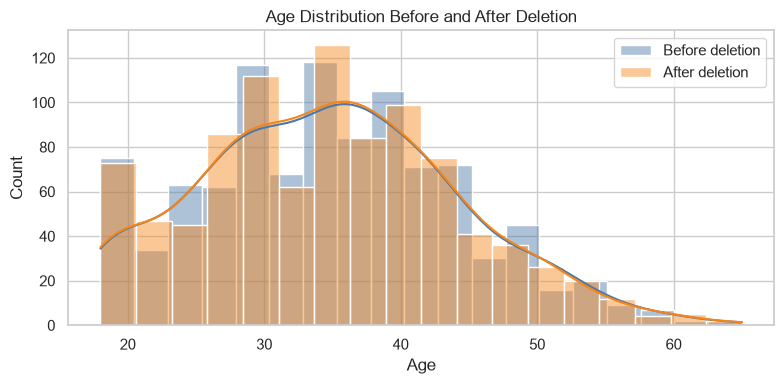

In [6]:
# Compare Age before and after deletion.
plt.figure(figsize=(8, 4))
sns.histplot(finance["Age"], kde=True, label="Before deletion", color="#4C78A8", alpha=0.45)
sns.histplot(
    finance_after_credit_score_deletion["Age"],
    kde=True,
    label="After deletion",
    color="#F58518",
    alpha=0.45,
)
plt.title("Age Distribution Before and After Deletion")
plt.legend()
plt.tight_layout()
plt.show()

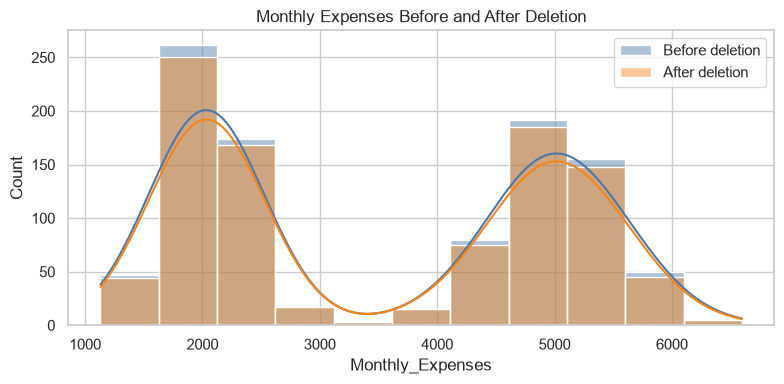

In [7]:
# Compare Monthly_Expenses before and after deletion.
plt.figure(figsize=(8, 4))
sns.histplot(finance["Monthly_Expenses"], kde=True, label="Before deletion", color="#4C78A8", alpha=0.45)
sns.histplot(
    finance_after_credit_score_deletion["Monthly_Expenses"],
    kde=True,
    label="After deletion",
    color="#F58518",
    alpha=0.45,
)
plt.title("Monthly Expenses Before and After Deletion")
plt.legend()
plt.tight_layout()
plt.show()

Loan_Type proportions before and after deletion:
               Before deletion  After deletion
Loan_Type                                     
Personal Loan            0.615        0.618848
Home Loan                0.281        0.279581
Auto Loan                0.104        0.101571


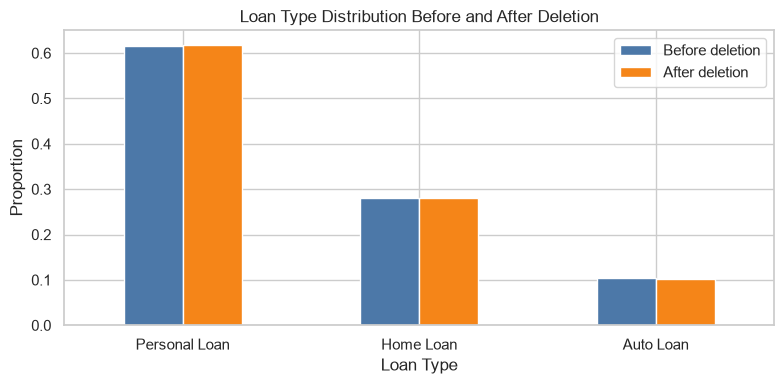

In [8]:
# Compare the categorical Loan_Type distribution before and after deletion.
loan_type_before = finance["Loan_Type"].value_counts(normalize=True)
loan_type_after = finance_after_credit_score_deletion["Loan_Type"].value_counts(normalize=True)

loan_type_comparison = pd.DataFrame({
    "Before deletion": loan_type_before,
    "After deletion": loan_type_after,
})

print("Loan_Type proportions before and after deletion:")
print(loan_type_comparison)

loan_type_comparison.plot(kind="bar", figsize=(8, 4), color=["#4C78A8", "#F58518"])
plt.title("Loan Type Distribution Before and After Deletion")
plt.xlabel("Loan Type")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

From all above visual outputs, it is clear that deletion does not have a very big effect on the underlying distribution of our data.

This means that - we can now reliably apply listwise deletion on the original data itself

In [8]:
# Now apply listwise deletion to remove all rows with missing values.
finance_cleaned = finance.dropna().copy()

print("Missing value percentage after listwise deletion:")
print((finance_cleaned.isnull().sum() / len(finance_cleaned)) * 100)
print("\nFinal cleaned shape:", finance_cleaned.shape)

Missing value percentage after listwise deletion:
Age                 0.0
Monthly_Expenses    0.0
Credit_Score        0.0
Loan_Type           0.0
Default             0.0
dtype: float64

Final cleaned shape: (955, 5)


Since before/after distributions are close and the missing percentage is below 5%

so listwise deletion is acceptable for this example.

## 3. Univariate Imputation

Univariate imputation fills a missing value by using information from the same
column. The chapter uses three common strategies:

- **mean** for roughly symmetric numerical features
- **median** for skewed numerical features or features with outliers
- **most frequent** for categorical features

In [9]:
# Load the loan dataset used for imputation examples.

loan_data_url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch07/loan.csv'

loan = pd.read_csv(loan_data_url)

print("Loan dataset preview:")
print(loan.head())

print("\nInfo:")
loan.info()

Loan dataset preview:
    Age  Monthly_Expenses   Income      Loan_Type  Default
0  39.0               NaN  72517.0      Home Loan        0
1  33.0            3465.0  20000.0      Auto Loan        0
2   NaN            3019.0  47109.0      Auto Loan        0
3  50.0            3005.0  20000.0  Personal Loan        0
4  32.0            3133.0  69590.0      Auto Loan        0

Info:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               405 non-null    float64
 1   Monthly_Expenses  475 non-null    float64
 2   Income            480 non-null    float64
 3   Loan_Type         488 non-null    str    
 4   Default           500 non-null    int64  
dtypes: float64(3), int64(1), str(1)
memory usage: 19.7 KB


It is clear that columns such as `Age` , `Monthly_Expenses` , `Income` and `Loan_Type` have missing data.

In [10]:
# Before imputation, let's see missing percentages in each column
loan_missing_percent = (loan.isnull().sum() / len(loan)) * 100

print("Missing value percentage before imputation:")
print(loan_missing_percent)

Missing value percentage before imputation:
Age                 19.0
Monthly_Expenses     5.0
Income               4.0
Loan_Type            2.4
Default              0.0
dtype: float64


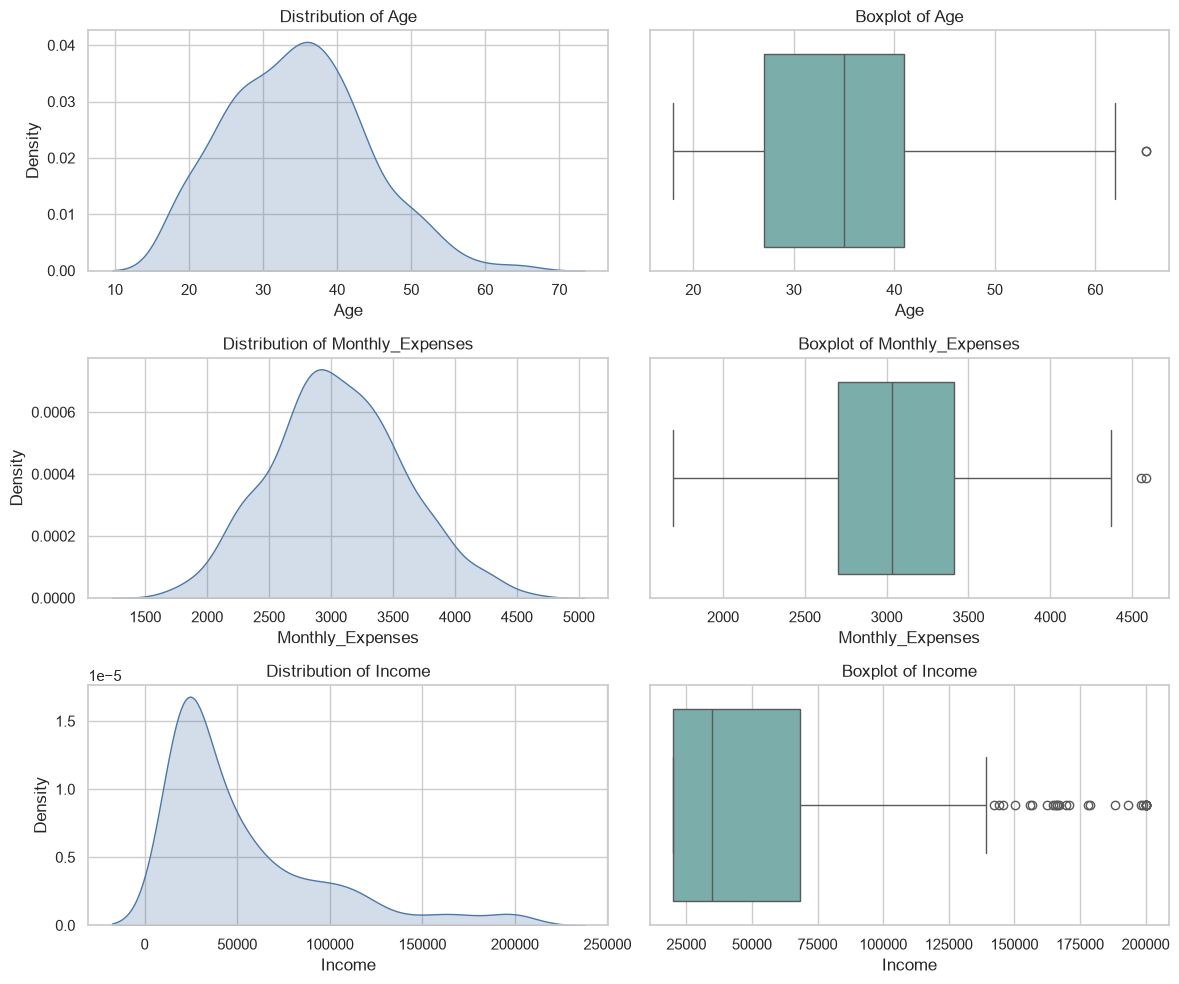

In [11]:
# Study the numerical distributions before choosing imputation strategies.
numerical_features = ["Age", "Monthly_Expenses", "Income"]

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for row, feature in enumerate(numerical_features):
    sns.kdeplot(data=loan, x=feature, fill=True, color="#4C78A8", ax=axes[row, 0])
    axes[row, 0].set_title(f"Distribution of {feature}")

    sns.boxplot(data=loan, x=feature, color="#72B7B2", ax=axes[row, 1])
    axes[row, 1].set_title(f"Boxplot of {feature}")

plt.tight_layout()
plt.show()

Loan_Type distribution before imputation:
Loan_Type
Personal Loan    0.334
Auto Loan        0.330
Home Loan        0.312
NaN              0.024
Name: proportion, dtype: float64


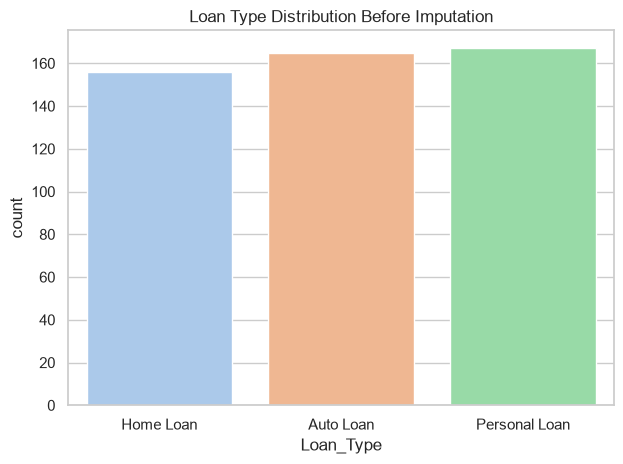

In [12]:
# Check the categorical feature before mode imputation.
print("Loan_Type distribution before imputation:")
print(loan["Loan_Type"].value_counts(normalize=True, dropna=False))

sns.countplot(data=loan, x="Loan_Type", hue="Loan_Type", palette="pastel", legend=False)
plt.title("Loan Type Distribution Before Imputation")
plt.tight_layout()
plt.show()

From these checks, we use the chapter's choices:

- `Age` and `Monthly_Expenses`: mean imputation
- `Income`: median imputation
- `Loan_Type`: most-frequent imputation

We create new columns instead of overwriting the originals so the before/after
comparison remains visible.

In [13]:
# Apply the imputers and create new imputed columns.
loan_imputed = loan.copy()

mean_imputer = SimpleImputer(strategy="mean")
median_imputer = SimpleImputer(strategy="median")
mode_imputer = SimpleImputer(strategy="most_frequent")

loan_imputed["Age_imputed"] = mean_imputer.fit_transform(loan_imputed[["Age"]]).ravel()
loan_imputed["Monthly_Expenses_imputed"] = mean_imputer.fit_transform(loan_imputed[["Monthly_Expenses"]]).ravel()
loan_imputed["Income_imputed"] = median_imputer.fit_transform(loan_imputed[["Income"]]).ravel()
loan_imputed["Loan_Type_imputed"] = mode_imputer.fit_transform(loan_imputed[["Loan_Type"]]).ravel()

print("Before imputation, selected rows with missing values:")
print(loan[loan.isnull().any(axis=1)].head())

print("\nAfter imputation, the same rows include imputed columns:")
print(loan_imputed.loc[loan.isnull().any(axis=1)].head())

Before imputation, selected rows with missing values:
     Age  Monthly_Expenses   Income      Loan_Type  Default
0   39.0               NaN  72517.0      Home Loan        0
2    NaN            3019.0  47109.0      Auto Loan        0
11   NaN            4302.0  20000.0      Home Loan        0
15   NaN            3307.0  71230.0      Home Loan        0
20   NaN            2966.0  20000.0  Personal Loan        0

After imputation, the same rows include imputed columns:
     Age  Monthly_Expenses   Income      Loan_Type  Default  Age_imputed  Monthly_Expenses_imputed  Income_imputed  \
0   39.0               NaN  72517.0      Home Loan        0    39.000000               3052.115789         72517.0   
2    NaN            3019.0  47109.0      Auto Loan        0    34.548148               3019.000000         47109.0   
11   NaN            4302.0  20000.0      Home Loan        0    34.548148               4302.000000         20000.0   
15   NaN            3307.0  71230.0      Home Loan      

In [14]:
# Verify that the new imputed columns have no missing values.
imputed_columns = [
    "Age_imputed",
    "Monthly_Expenses_imputed",
    "Income_imputed",
    "Loan_Type_imputed",
]

print("Missing values in imputed columns:")
print(loan_imputed[imputed_columns].isnull().sum())

Missing values in imputed columns:
Age_imputed                 0
Monthly_Expenses_imputed    0
Income_imputed              0
Loan_Type_imputed           0
dtype: int64


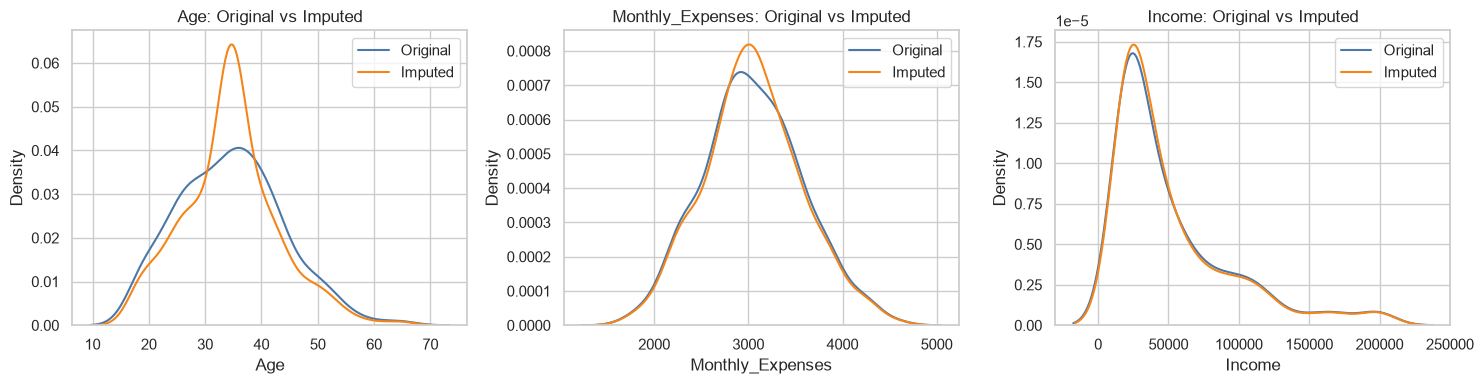

In [15]:
# Compare numerical distributions before and after imputation.
comparison_pairs = [
    ("Age", "Age_imputed"),
    ("Monthly_Expenses", "Monthly_Expenses_imputed"),
    ("Income", "Income_imputed"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (original_col, imputed_col) in zip(axes, comparison_pairs):
    sns.kdeplot(loan_imputed[original_col], label="Original", color="#4C78A8", ax=ax)
    sns.kdeplot(loan_imputed[imputed_col], label="Imputed", color="#F58518", ax=ax)
    ax.set_title(f"{original_col}: Original vs Imputed")
    ax.legend()

plt.tight_layout()
plt.show()

In [16]:
# Compare categorical proportions before and after mode imputation.
loan_type_imputation_comparison = pd.DataFrame({
    "Original Loan_Type": loan_imputed["Loan_Type"].value_counts(normalize=True),
    "Imputed Loan_Type": loan_imputed["Loan_Type_imputed"].value_counts(normalize=True),
})

print("Loan_Type proportions before and after imputation:")
print(loan_type_imputation_comparison)

Loan_Type proportions before and after imputation:
               Original Loan_Type  Imputed Loan_Type
Personal Loan            0.342213              0.358
Auto Loan                0.338115              0.330
Home Loan                0.319672              0.312


Mean imputation is easy to apply, but it can create a visible peak when many
values are missing, as seen with `Age`. `Monthly_Expenses`, `Income`, and
`Loan_Type` preserve their distributions better because their missing
percentages are smaller and the chosen strategies match their data types.

## 4. Multivariate Imputation with KNNImputer

Multivariate imputation uses other columns to estimate the missing value.
`KNNImputer` fills a missing value by finding nearby rows and averaging the
available values from those neighbors.

In [17]:
# A small example makes the KNN idea easy to inspect manually.
knn_example = pd.DataFrame({
    "Age": [25, 30, 35, 40],
    "Experience": [2, 5, 10, np.nan],
    "Income": [50000, 60000, np.nan, 80000],
})

print("Original dataset with missing values:")
print(knn_example)

Original dataset with missing values:
   Age  Experience   Income
0   25         2.0  50000.0
1   30         5.0  60000.0
2   35        10.0      NaN
3   40         NaN  80000.0


In [18]:
# Apply KNN imputation with two neighbors.
knn_imputer = KNNImputer(n_neighbors=2)
knn_imputed_array = knn_imputer.fit_transform(knn_example)
knn_imputed = pd.DataFrame(knn_imputed_array, columns=knn_example.columns)

print("Dataset after KNN imputation:")
print(knn_imputed)

Dataset after KNN imputation:
    Age  Experience   Income
0  25.0         2.0  50000.0
1  30.0         5.0  60000.0
2  35.0        10.0  70000.0
3  40.0         7.5  80000.0


In [19]:
# Show the exact before/after rows where KNNImputer filled values.
missing_rows = knn_example.isnull().any(axis=1)

print("Rows before KNN imputation:")
print(knn_example[missing_rows])
print("\nSame rows after KNN imputation:")
print(knn_imputed[missing_rows])

Rows before KNN imputation:
   Age  Experience   Income
2   35        10.0      NaN
3   40         NaN  80000.0

Same rows after KNN imputation:
    Age  Experience   Income
2  35.0        10.0  70000.0
3  40.0         7.5  80000.0


KNN imputation is useful when similar rows carry useful information about the
missing value. It is less suitable for very large, high-dimensional, or mostly
categorical datasets because distance calculations become less reliable or more
expensive.

## 5. What Outliers Do

An outlier is a value that is far away from the usual pattern of a feature.
Outliers can be valid rare cases, or they can be data errors. The chapter uses
a three-step process: detect, diagnose, and treat.

Two foundational detection rules are used here:

- **Z-score** for roughly normal numerical features
- **IQR** for skewed numerical features

In [22]:
# Load the customer dataset used for outlier examples.
customer_data_url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch07/customer.csv'
customer = pd.read_csv(customer_data_url)

print("Customer dataset preview:")
print(customer.head())

print("\nShape:", customer.shape)

Customer dataset preview:
         Age         Income  Purchased
0  39.967142   78033.985988          0
1  33.617357  261173.924513          1
2  41.476885   35891.567445          1
3  50.230299   67563.459278          0
4  32.658466  137995.909721          0

Shape: (200, 3)


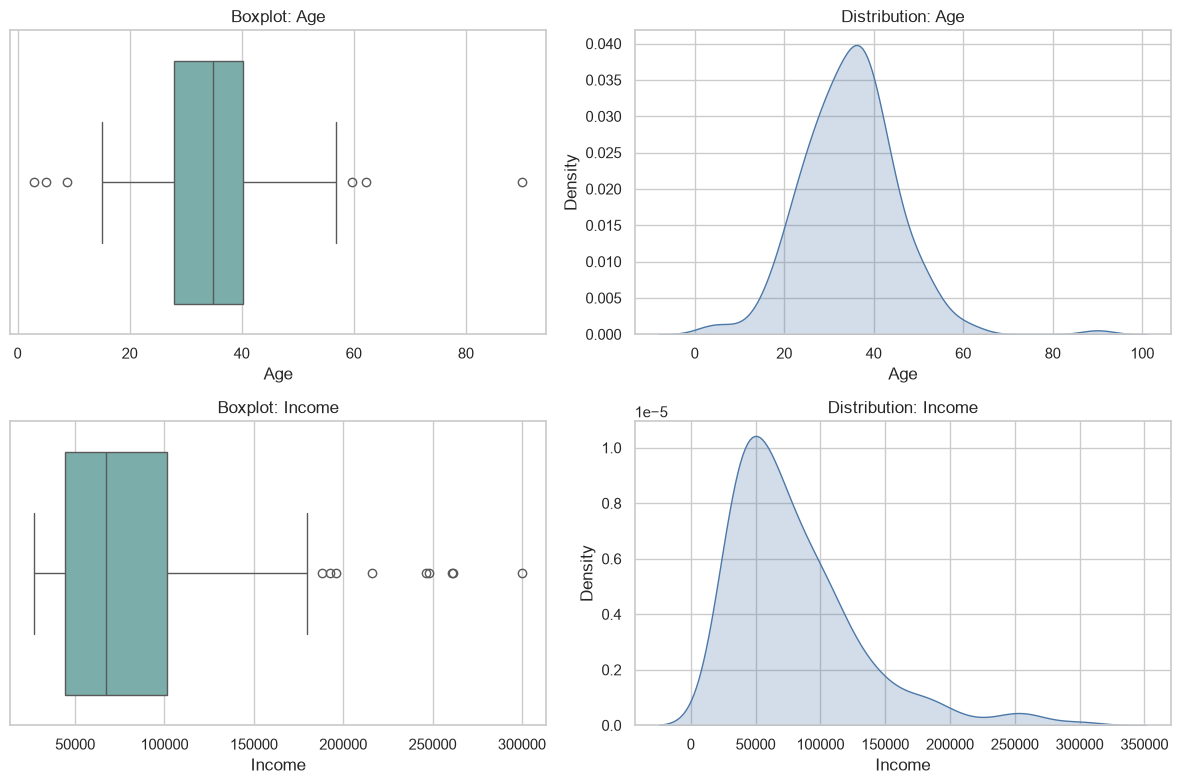

In [23]:
# Visualize Age and Income before detecting outliers.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(x=customer["Age"], color="#72B7B2", ax=axes[0, 0])
axes[0, 0].set_title("Boxplot: Age")

sns.kdeplot(customer["Age"], fill=True, color="#4C78A8", ax=axes[0, 1])
axes[0, 1].set_title("Distribution: Age")

sns.boxplot(x=customer["Income"], color="#72B7B2", ax=axes[1, 0])
axes[1, 0].set_title("Boxplot: Income")

sns.kdeplot(customer["Income"], fill=True, color="#4C78A8", ax=axes[1, 1])
axes[1, 1].set_title("Distribution: Income")

plt.tight_layout()
plt.show()

`Age` is approximately normal, so Z-score is a reasonable detection method.

`Income` is right-skewed, so IQR is better because it does not assume a normal
distribution.

In [24]:
# Detect Age outliers using the Z-score rule.
customer_outlier_work = customer.copy()

mean_age = customer_outlier_work["Age"].mean()
std_age = customer_outlier_work["Age"].std()
customer_outlier_work["Age_Z_Score"] = (customer_outlier_work["Age"] - mean_age) / std_age

age_outliers = customer_outlier_work[
    (customer_outlier_work["Age_Z_Score"] > 3) | (customer_outlier_work["Age_Z_Score"] < -3)
]

print("Age outliers detected by Z-score:")
print(age_outliers)
print("\nNumber of Age outliers:", len(age_outliers))

Age outliers detected by Z-score:
      Age        Income  Purchased  Age_Z_Score
197  90.0  62292.923803          0      5.24624

Number of Age outliers: 1


In [25]:
# Detect Income outliers using the IQR rule.
q1_income = customer_outlier_work["Income"].quantile(0.25)
q3_income = customer_outlier_work["Income"].quantile(0.75)
iqr_income = q3_income - q1_income

lower_bound_income = q1_income - 1.5 * iqr_income
upper_bound_income = q3_income + 1.5 * iqr_income

income_outliers = customer_outlier_work[
    (customer_outlier_work["Income"] < lower_bound_income)
    | (customer_outlier_work["Income"] > upper_bound_income)
]

print("Income IQR bounds:")
print({"lower_bound": float(lower_bound_income), "upper_bound": float(upper_bound_income)})
print("\nIncome outliers detected by IQR:")
print(income_outliers)
print("\nNumber of Income outliers:", len(income_outliers))

Income IQR bounds:
{'lower_bound': -40963.51266731775, 'upper_bound': 186406.97021343285}

Income outliers detected by IQR:
           Age         Income  Purchased  Age_Z_Score
1    33.617357  261173.924513          1    -0.096684
45   27.801558  216188.337834          0    -0.647800
50   45.000000  300000.000000          0     0.981957
53   41.116763  195792.225920          0     0.613974
64   43.125258  188415.856613          0     0.804303
106  53.861859  192882.552897          1     1.821723
130  19.493366  260687.148500          1    -1.435099
181  26.428424  247785.513721          0    -0.777920
186  39.732376  246321.834221          0     0.482787

Number of Income outliers: 9


After detection, we decide how to treat the outliers.

The chapter demonstrates two common treatments: removal and capping. 

Removal drops the outlier rows; capping keeps the rows but limits extreme values to a boundary.

In [26]:
# Before treatment, show the current ranges.
print("Before outlier treatment:")
print(customer_outlier_work[["Age", "Income"]].describe())

Before outlier treatment:
              Age         Income
count  200.000000     200.000000
mean    34.637638   80203.240731
std     10.552770   49702.888022
min      3.000000   27207.425013
25%     27.842754   44300.418413
50%     34.799944   67182.058853
75%     40.270962  101143.039133
max     90.000000  300000.000000


In [27]:
# Removal: remove Age outliers by Z-score and Income outliers by IQR bounds.
customer_without_outliers = customer_outlier_work[
    ~((customer_outlier_work["Age_Z_Score"] > 3) | (customer_outlier_work["Age_Z_Score"] < -3))
].copy()

customer_without_outliers = customer_without_outliers[
    ~(
        (customer_without_outliers["Income"] < lower_bound_income)
        | (customer_without_outliers["Income"] > upper_bound_income)
    )
].copy()

print("After removal shape:", customer_without_outliers.shape)
print("Rows removed:", len(customer_outlier_work) - len(customer_without_outliers))
print("\nRanges after removal:")
print(customer_without_outliers[["Age", "Income"]].describe())

After removal shape: (190, 4)
Rows removed: 10

Ranges after removal:
              Age         Income
count  190.000000     190.000000
mean    34.249214   72995.304358
std      9.787622   36791.916333
min      3.000000   27207.425013
25%     27.887232   40915.459809
50%     34.693872   63692.213029
75%     39.931537   95624.567156
max     62.201692  179945.662415


In [28]:
# Capping: keep all rows but clip extreme values to accepted boundaries.
customer_capped = customer_outlier_work.copy()
customer_capped["Age"] = customer_capped["Age"].clip(
    lower=mean_age - 3 * std_age,
    upper=mean_age + 3 * std_age,
)
customer_capped["Income"] = customer_capped["Income"].clip(
    lower=lower_bound_income,
    upper=upper_bound_income,
)

print("Before capping, rows that needed treatment:")
outlier_indexes = sorted(set(age_outliers.index).union(set(income_outliers.index)))
print(customer_outlier_work.loc[outlier_indexes, ["Age", "Income", "Age_Z_Score"]])

print("\nAfter capping, the same rows are limited to the boundaries:")
print(customer_capped.loc[outlier_indexes, ["Age", "Income", "Age_Z_Score"]])

Before capping, rows that needed treatment:
           Age         Income  Age_Z_Score
1    33.617357  261173.924513    -0.096684
45   27.801558  216188.337834    -0.647800
50   45.000000  300000.000000     0.981957
53   41.116763  195792.225920     0.613974
64   43.125258  188415.856613     0.804303
106  53.861859  192882.552897     1.821723
130  19.493366  260687.148500    -1.435099
181  26.428424  247785.513721    -0.777920
186  39.732376  246321.834221     0.482787
197  90.000000   62292.923803     5.246240

After capping, the same rows are limited to the boundaries:
           Age         Income  Age_Z_Score
1    33.617357  186406.970213    -0.096684
45   27.801558  186406.970213    -0.647800
50   45.000000  186406.970213     0.981957
53   41.116763  186406.970213     0.613974
64   43.125258  186406.970213     0.804303
106  53.861859  186406.970213     1.821723
130  19.493366  186406.970213    -1.435099
181  26.428424  186406.970213    -0.777920
186  39.732376  186406.970213     0

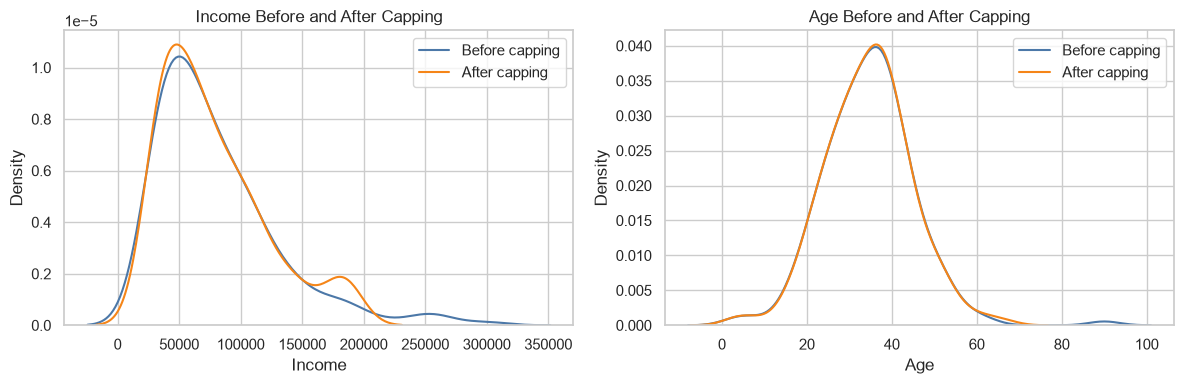

In [29]:
# Compare distributions after capping.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(customer_outlier_work["Income"], label="Before capping", color="#4C78A8", ax=axes[0])
sns.kdeplot(customer_capped["Income"], label="After capping", color="#F58518", ax=axes[0])
axes[0].set_title("Income Before and After Capping")
axes[0].legend()

sns.kdeplot(customer_outlier_work["Age"], label="Before capping", color="#4C78A8", ax=axes[1])
sns.kdeplot(customer_capped["Age"], label="After capping", color="#F58518", ax=axes[1])
axes[1].set_title("Age Before and After Capping")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Chapter Wrap-Up

This chapter showed that missing values and outliers should not be handled
blindly. We first inspect the data, choose a method that matches the feature,
then verify the before/after effect.

Key takeaways:

- deletion is useful only when the missing percentage is small and the deleted
  rows do not distort the data
- mean, median, and mode imputation are simple univariate methods
- KNN imputation uses relationships between columns
- Z-score works best for roughly normal features
- IQR is useful for skewed features
- outliers can be removed or capped after diagnosing their nature